# 07 · The full QSS tier (T1) — capstone

Everything milestone M3 built, in one walkthrough. The T1 tier solves a **double-track trim** at
every station — per-wheel loads and slips, quasi-static load transfer, the powertrain through the
drivetrain graph — and compiles the car's capability into a **g-g-g-v envelope** the lap solver
rides. First the F1 reference car on the 3D Catalunya ribbon; then an **electrified road car**,
the Tesla Model 3 RWD (HV variant), where the battery pack, the Vdc–SoC coupling, and the
machine-thermal derate are *live*, swept across three drive-unit sizings.

Theory pages: [`t1-trim.md`](../docs/theory/t1-trim.md) ·
[`ggv-envelope.md`](../docs/theory/ggv-envelope.md) ·
[`qss-powertrain.md`](../docs/theory/qss-powertrain.md) ·
[`machine-thermal.md`](../docs/theory/machine-thermal.md)

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# CI-speed solver pin: every distinct vehicle/override combination regenerates its g-g-g-v
# envelope (the cold assembly step), and this notebook touches five of them (F1 + Model 3 x 3
# sizings), so everything runs on a coarse envelope grid. The production default (40x25x7) is
# what `solve_lap_dataset(...)` gives with no `sim=` argument.
FAST_SIM = {"envelope": {"v_points": 8, "ax_points": 7, "g_normal_points": 2}}

# Validated reference palette (light mode) — same style as the tour notebook.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED = "#2a78d6", "#1baf7a", "#e34948"
LOADS5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # ordinal, 5 steps
SEQ = LinearSegmentedColormap.from_list(
    "outlap_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update(
    {
        "figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "font.size": 10.5,
        "legend.frameon": False, "lines.linewidth": 2.0,
    }
)

from outlap.core import Track, min_curvature, solve_lap, solve_lap_dataset, vehicle_report

F1 = str(ROOT / "data" / "vehicles" / "f1_2026")
MODEL3 = str(ROOT / "data" / "vehicles" / "tesla_model3_rwd")

catalunya = Track.load(str(ROOT / "data" / "tracks" / "catalunya_osm"))
ring = Track.load(str(ROOT / "data" / "tracks" / "nuerburgring"))
rl_cat = min_curvature(catalunya, half_width_m=1.1)
rl_ring = min_curvature(ring, half_width_m=1.5)

f1 = solve_lap_dataset(F1, rl_cat, tier="t1", sim=FAST_SIM)
print(f"F1 on Catalunya (3D): {f1.attrs['lap_time_s']:.2f} s, tier={f1.attrs['tier']}")
assert 60.0 < f1.attrs["lap_time_s"] < 120.0, "F1 sanity band"
assert f1.attrs["tier"] == "t1"

F1 on Catalunya (3D): 110.87 s, tier=t1


## Per-wheel loads on the 3D ribbon

T0 saw the car as a point. T1 sees four contact patches: at every solved station the trim is
re-run at the lap's `(v, a_x, a_y, g_normal)` and emits each wheel's **normal load** — the
geometric + elastic load transfer plus the aero platform, on the real grade and banking of the
OSM+DEM Catalunya import. Braking piles load on the front axle; the long right-handers load the
left side. (Gaps are stations whose re-trim sits outside the interpolated envelope's feasible
hull — flagged, never invented.)

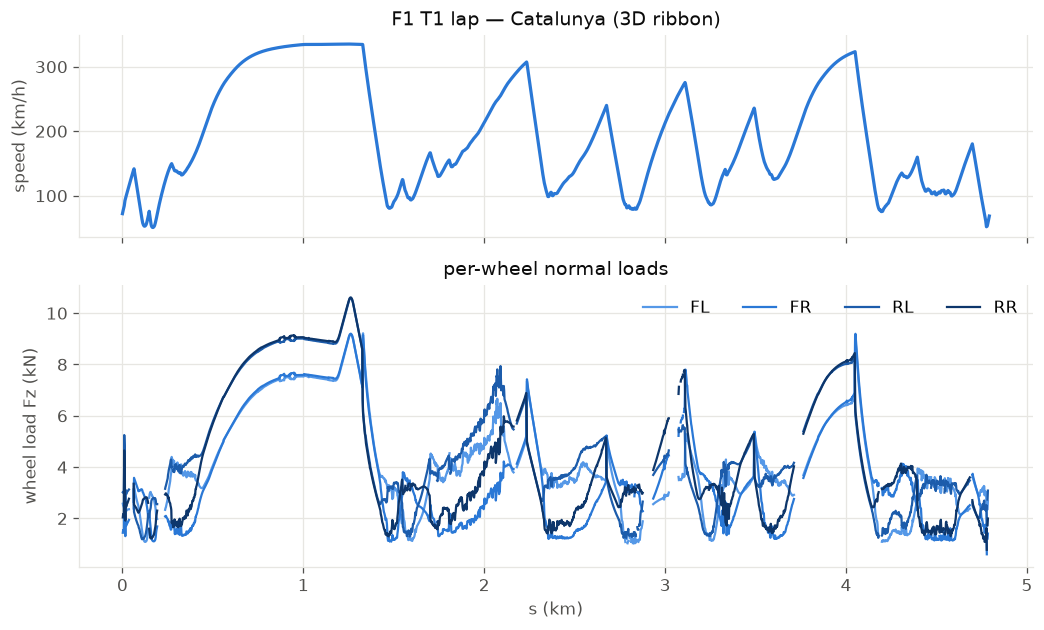

In [2]:
s_km = f1.s.to_numpy() / 1e3
fig, (a, b) = plt.subplots(2, 1, figsize=(9.2, 5.6), sharex=True,
                           gridspec_kw={"height_ratios": [1, 1.4]})
a.plot(s_km, f1.v.to_numpy() * 3.6, color=BLUE)
a.set_ylabel("speed (km/h)")
a.set_title("F1 T1 lap — Catalunya (3D ribbon)")

wheel_colors = dict(zip(["FL", "FR", "RL", "RR"], [LOADS5[1], LOADS5[2], LOADS5[3], LOADS5[4]]))
for w, c in wheel_colors.items():
    b.plot(s_km, f1.vertical_load_n.sel(wheel=w).to_numpy() / 1e3, color=c, lw=1.4, label=w)
b.set_xlabel("s (km)")
b.set_ylabel("wheel load Fz (kN)")
b.set_title("per-wheel normal loads")
b.legend(ncols=4)
plt.tight_layout()
plt.show()

fz = f1.vertical_load_n.to_numpy()
ok = np.isfinite(fz).all(axis=1)
assert ok.mean() > 0.9, "most stations must re-trim feasibly"
assert float(np.nanmin(fz)) > 0.0, "no wheel lifts on a QSS lap"

## Setup metrics: understeer gradient and aero balance

Because the trim is a full force–moment balance, engineering metrics fall out of it directly.
The **understeer gradient** `K = dδ/da_y − L/v²` is probed at each station's operating point,
and the **aero balance** (front axle's share of total downforce) comes from the ride-height map
platform equilibrium — the F1 map shifts balance with speed as the platform compresses.

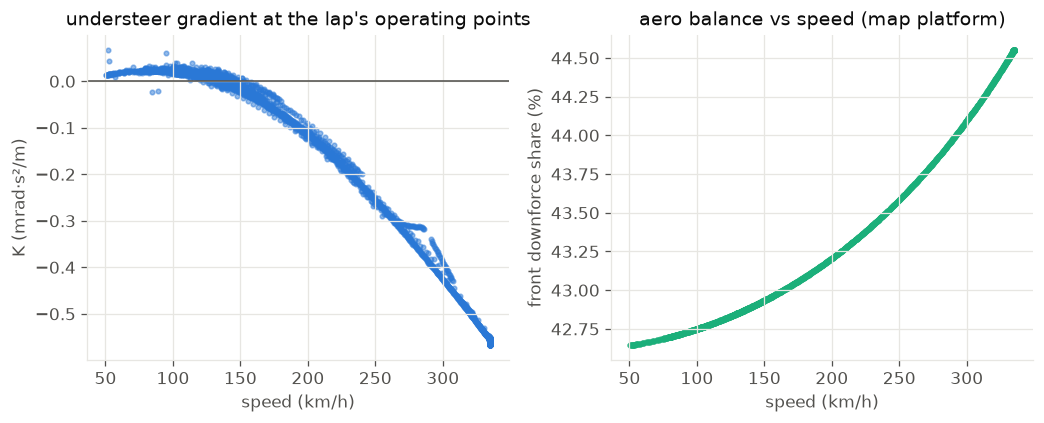

In [3]:
v_kmh = f1.v.to_numpy() * 3.6
ug = f1.understeer_gradient.to_numpy()
share = f1.aero_front_share.to_numpy()

fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.8))
a.scatter(v_kmh, ug * 1e3, s=8, color=BLUE, alpha=0.5)
a.axhline(0.0, color=INK2, lw=1.0)
a.set_xlabel("speed (km/h)")
a.set_ylabel("K (mrad·s²/m)")
a.set_title("understeer gradient at the lap's operating points")

b.scatter(v_kmh, share * 100, s=8, color=AQUA, alpha=0.5)
b.set_xlabel("speed (km/h)")
b.set_ylabel("front downforce share (%)")
b.set_title("aero balance vs speed (map platform)")
plt.tight_layout()
plt.show()

fin = np.isfinite(share)
assert fin.any() and (share[fin] > 0.0).all() and (share[fin] < 1.0).all()

## The g-g-g-v envelope, first-class

The lap solver doesn't call the trim in its hot loop — it rides a precompiled **g-g-g-v**
boundary: the feasible `(a_x, a_y)` set per speed and road-normal gravity (banking/crests change
what the tyres can give — that's the third *g*). The envelope is returnable and queryable from
Python:

domain: v ∈ [5, 91] m/s, g_normal ∈ [4.9, 19.6] m/s², grid [8, 7, 2]


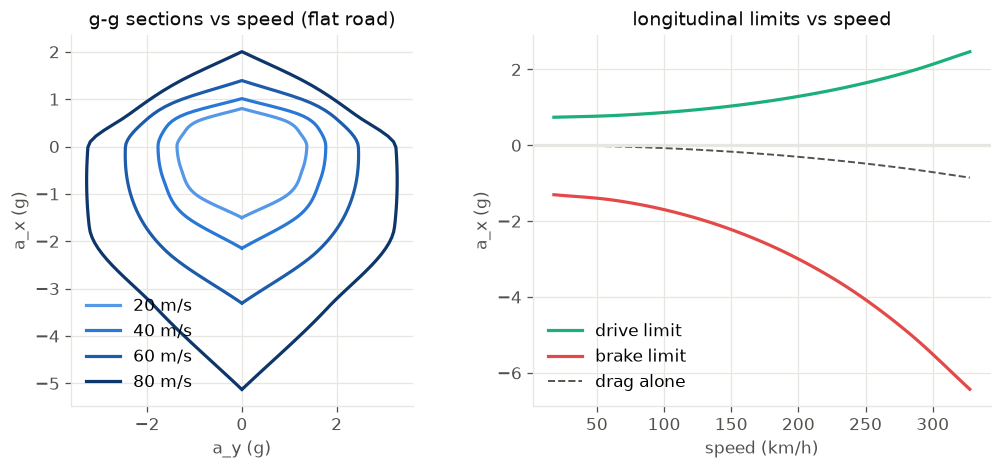

In [4]:
lap_obj = solve_lap(F1, rl_cat.line(), raceline_ds_m=rl_cat.ds_m, tier="t1", sim=FAST_SIM)
env = lap_obj.envelope
(v_lo, v_hi), _, (gn_lo, gn_hi) = env.domain()
print(f"domain: v ∈ [{v_lo:.0f}, {v_hi:.0f}] m/s, g_normal ∈ [{gn_lo:.1f}, {gn_hi:.1f}] m/s², "
      f"grid {env.shape()}")

GN = 9.81
fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 4.2))
speeds = [20.0, 40.0, 60.0, 80.0]
for v, c in zip(speeds, LOADS5[1:]):
    acc, brk = env.accel_limit(v, GN), env.brake_limit(v, GN)
    ax_grid = np.linspace(-brk, acc, 61)
    ay = np.array([env.ay_boundary(v, a, GN) for a in ax_grid])
    a.plot(np.r_[ay, -ay[::-1]] / GN, np.r_[ax_grid, ax_grid[::-1]] / GN,
           color=c, label=f"{v:.0f} m/s")
a.set_xlabel("a_y (g)")
a.set_ylabel("a_x (g)")
a.set_title("g-g sections vs speed (flat road)")
a.set_aspect("equal")
a.legend()

vv = np.linspace(v_lo, v_hi, 80)
b.plot(vv * 3.6, [env.accel_limit(v, GN) / GN for v in vv], color=AQUA, label="drive limit")
b.plot(vv * 3.6, [-env.brake_limit(v, GN) / GN for v in vv], color=RED, label="brake limit")
b.plot(vv * 3.6, [-env.drag_accel(v) / GN for v in vv], color=INK2, lw=1.2, ls="--",
       label="drag alone")
b.axhline(0.0, color=GRID)
b.set_xlabel("speed (km/h)")
b.set_ylabel("a_x (g)")
b.set_title("longitudinal limits vs speed")
b.legend()
plt.tight_layout()
plt.show()

assert env.ay_boundary(40.0, 0.0, GN) > GN, "an F1 corners above 1 g at 40 m/s"

## An electrified road car: Tesla Model 3 RWD (HV variant)

Same tier, same code path, radically different car — that's the point of one vehicle
description. The committed Model 3 is an **HV (800 V-class) variant study**: Model-3-plausible
chassis and aero (spec-sheet values vs documented estimates — see the
[per-parameter provenance](../data/vehicles/tesla_model3_rwd/README.md)), and a **synthetic**
drive-unit + pack stack written by a committed generator
(`python/tools/gen_model3_powertrain.py`) — never PDT-derived data.

On this car the M3 slow states are live end-to-end: the drive-unit maps carry a **Vdc axis**, so
torque, efficiency, and heating are evaluated at the pack's SoC-dependent terminal voltage
(627–807 V, deliberately undershooting the 730–850 V map grid at low SoC — the below-grid linear
extrapolation is part of the contract); the `.emotor` LPTN turns losses into winding temperature
and a **derate**; the pack's peak-power limit caps traction. The loaded-model report keeps every
estimate visible first:

Tesla Model 3 RWD (HV variant)  (resolved 76c65d2ac0a2…)
estimated (10 entries — noted, not warned):
  /suspension/front/static_ride_height_m     assumed 30 mm nominal (only used by the ride-height aero map)
  /suspension/front/anti_dive                assumed 0 (no anti-dive geometry)
  /suspension/front/anti_squat               assumed 0 (no anti-squat geometry)
  /suspension/front/camber_map               no camber map — assumed zero camber change with travel
  /suspension/front/toe_map                  no toe map — assumed zero toe change with travel
  /suspension/rear/static_ride_height_m      assumed 50 mm nominal (only used by the ride-height aero map)
  /suspension/rear/anti_dive                 assumed 0 (no anti-dive geometry)
  /suspension/rear/anti_squat                assumed 0 (no anti-squat geometry)
  /suspension/rear/camber_map                no camber map — assumed zero camber change with travel
  /suspension/rear/toe_map                   no toe map — assumed zero to

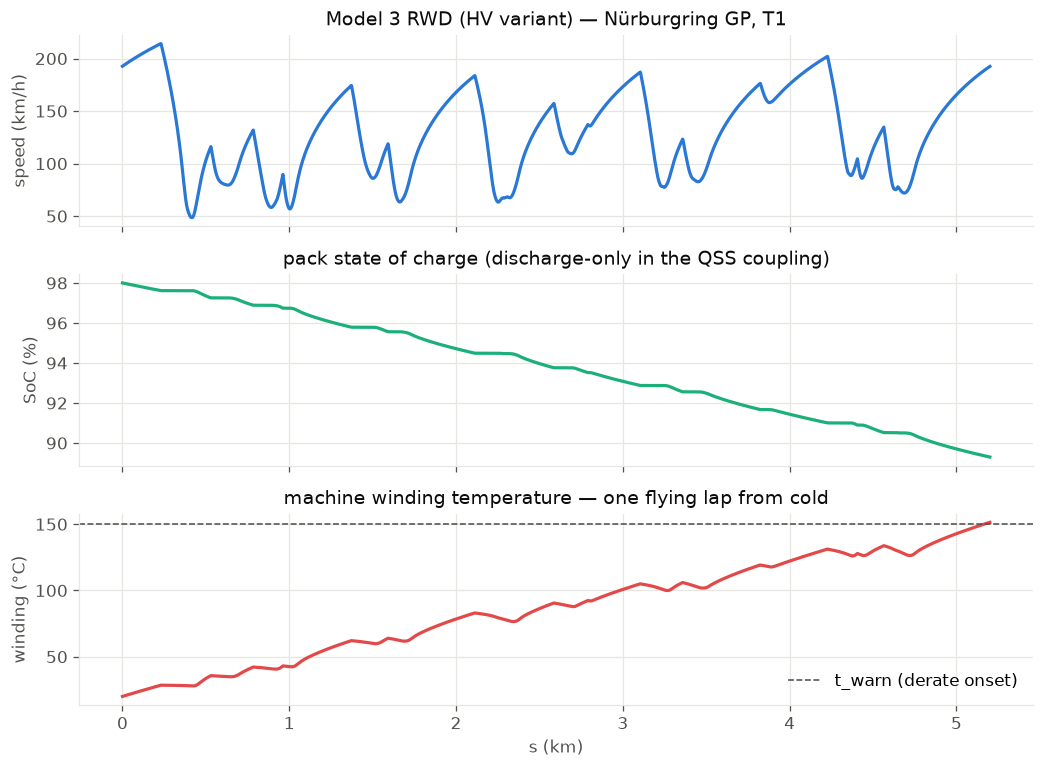

In [5]:
rep = vehicle_report(MODEL3)
print(f"{rep['name']}  (resolved {rep['resolved_hash'][:12]}…)")
assert rep["warnings"] == [] and rep["degraded"] == [], "loads warning-clean"
print(f"estimated ({len(rep['estimated'])} entries — noted, not warned):")
for ptr, detail in rep["estimated"]:
    print(f"  {ptr:42s} {detail}")

m3 = solve_lap_dataset(MODEL3, rl_ring, tier="t1", sim=FAST_SIM)
print(f"\nModel 3 (medium DU) on the Nürburgring GP: {m3.attrs['lap_time_s']:.2f} s")

s_km = m3.s.to_numpy() / 1e3
fig, axs = plt.subplots(3, 1, figsize=(9.2, 6.8), sharex=True)
axs[0].plot(s_km, m3.v.to_numpy() * 3.6, color=BLUE)
axs[0].set_ylabel("speed (km/h)")
axs[0].set_title("Model 3 RWD (HV variant) — Nürburgring GP, T1")
axs[1].plot(s_km, m3.state_of_charge.to_numpy() * 100, color=AQUA)
axs[1].set_ylabel("SoC (%)")
axs[1].set_title("pack state of charge (discharge-only in the QSS coupling)")
axs[2].plot(s_km, m3.machine_temp_c.to_numpy(), color=RED)
axs[2].axhline(150.0, color=INK2, lw=1.0, ls="--", label="t_warn (derate onset)")
axs[2].set_xlabel("s (km)")
axs[2].set_ylabel("winding (°C)")
axs[2].set_title("machine winding temperature — one flying lap from cold")
axs[2].legend()
plt.tight_layout()
plt.show()

soc = m3.state_of_charge.to_numpy()
assert np.all(np.diff(soc) <= 1e-12) and soc[-1] < soc[0], "monotone discharge"
assert float(m3.machine_temp_c.max()) < 180.0, "winding stays below t_max"

## Sizing sensitivity: three synthetic drive units

The vehicle ships three drive-unit sizings (small / medium / large ≈ 100 / 203 / 248 kW at the
output shaft — the same peak-torque scales as the author's local real-map sweep, so this story
and its untracked real-data twin are directly comparable). Swapping one is a **what-if
override** — no file editing, full validation pipeline:

More torque buys less and less. Part of that is the ladder itself (the power steps shrink:
+103 kW, then +45 kW) — but the caps compound it: the bigger units run hotter (the winding
crosses the derate band) and push into the pack's electrical power ceiling, so the
medium→large step is worth much less **per kilowatt** than small→medium.

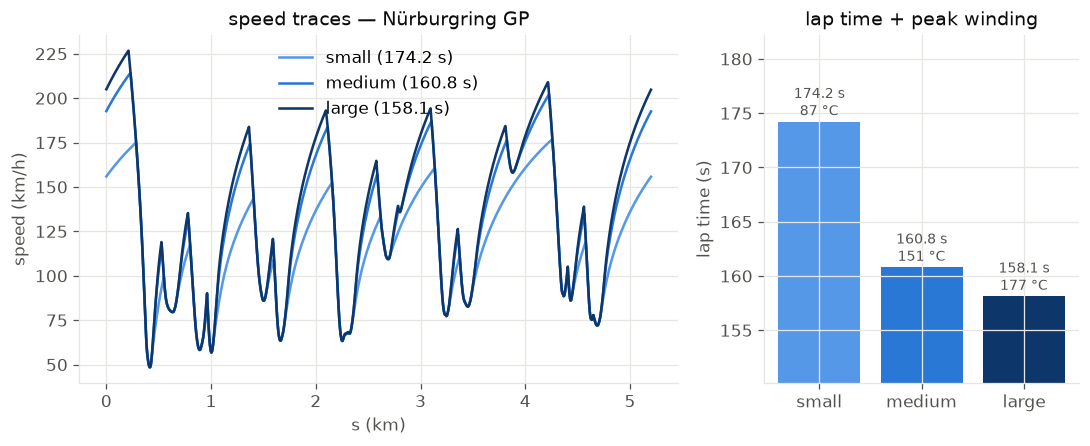

small→medium −13.41 s, medium→large −2.67 s


In [6]:
sizes = ["small", "medium", "large"]
laps = {"medium": m3}
for size in ("small", "large"):
    laps[size] = solve_lap_dataset(
        MODEL3, rl_ring, tier="t1", sim=FAST_SIM,
        overrides={"drivetrain.units.0.source": f"ptm/du_{size}.ptm.yaml"},
    )

fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 4.0), gridspec_kw={"width_ratios": [1.9, 1]})
for size, c in zip(sizes, [LOADS5[1], LOADS5[2], LOADS5[4]]):
    ds = laps[size]
    a.plot(ds.s.to_numpy() / 1e3, ds.v.to_numpy() * 3.6, color=c, lw=1.6,
           label=f"{size} ({ds.attrs['lap_time_s']:.1f} s)")
a.set_xlabel("s (km)")
a.set_ylabel("speed (km/h)")
a.set_title("speed traces — Nürburgring GP")
a.legend()

times = [laps[s].attrs["lap_time_s"] for s in sizes]
tmaxs = [float(laps[s].machine_temp_c.max()) for s in sizes]
bars = b.bar(sizes, times, color=[LOADS5[1], LOADS5[2], LOADS5[4]])
for r, t, tm in zip(bars, times, tmaxs):
    b.text(r.get_x() + r.get_width() / 2, t + 0.6, f"{t:.1f} s\n{tm:.0f} °C",
           ha="center", fontsize=9, color=INK2)
b.set_ylim(min(times) - 8, max(times) + 8)
b.set_ylabel("lap time (s)")
b.set_title("lap time + peak winding")
plt.tight_layout()
plt.show()

t_s, t_m, t_l = (laps[s].attrs["lap_time_s"] for s in sizes)
assert t_s > t_m > t_l, "more power ⇒ faster"
assert (t_s - t_m) > (t_m - t_l), "…with diminishing returns (thermal + battery caps)"
print(f"small→medium −{t_s - t_m:.2f} s, medium→large −{t_m - t_l:.2f} s")

## Two cars, one tier

The same solver, the same schemas, the same per-wheel physics — an F1 car on a 3D ribbon and a
road EV with a live electrified stack. (The F1's MGU-K is an ERS unit, not a drivetrain unit:
its deployment/harvest energy manager is the M6 milestone, so the slow-state channels here
belong to the EV.)

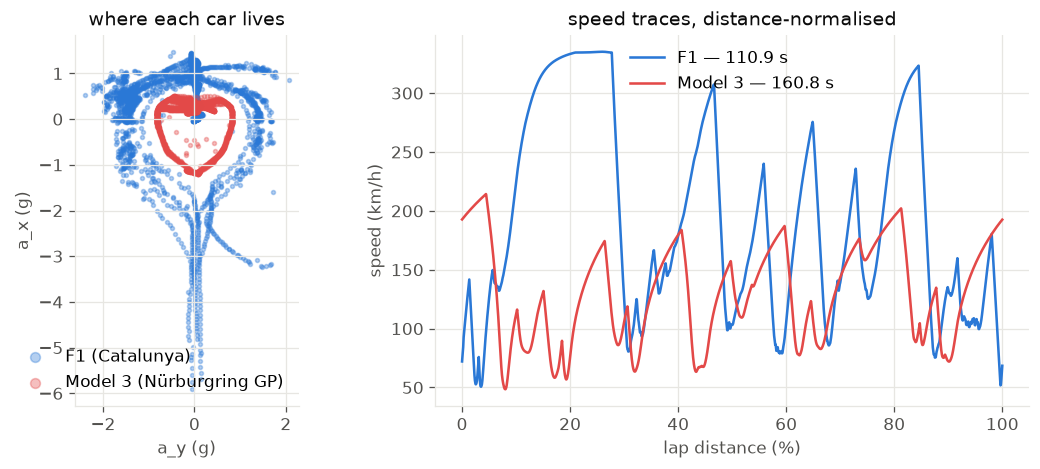

F1 peak |a_y| 2.4 g · Model 3 peak |a_y| 0.8 g


In [7]:
GN = 9.81
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 4.2), gridspec_kw={"width_ratios": [1, 1.4]})
a.scatter(f1.ay.to_numpy() / GN, f1.ax.to_numpy() / GN, s=6, alpha=0.35, color=BLUE,
          label="F1 (Catalunya)")
a.scatter(m3.ay.to_numpy() / GN, m3.ax.to_numpy() / GN, s=6, alpha=0.35, color=RED,
          label="Model 3 (Nürburgring GP)")
a.set_xlabel("a_y (g)")
a.set_ylabel("a_x (g)")
a.set_title("where each car lives")
a.set_aspect("equal")
a.legend(loc="lower right", markerscale=2.5)

for ds, c, name in ((f1, BLUE, "F1"), (m3, RED, "Model 3")):
    s = ds.s.to_numpy()
    b.plot(s / s[-1] * 100, ds.v.to_numpy() * 3.6, color=c, lw=1.6,
           label=f"{name} — {ds.attrs['lap_time_s']:.1f} s")
b.set_xlabel("lap distance (%)")
b.set_ylabel("speed (km/h)")
b.set_title("speed traces, distance-normalised")
b.legend()
plt.tight_layout()
plt.show()

print(f"F1 peak |a_y| {float(np.nanmax(np.abs(f1.ay))) / GN:.1f} g · "
      f"Model 3 peak |a_y| {float(np.nanmax(np.abs(m3.ay))) / GN:.1f} g")

---

**What this walkthrough exercised:** `sim.tier` dispatch → the T1 double-track trim (per-wheel
`Fz`/κ/α/forces + understeer gradient + aero balance) → the returnable g-g-g-v envelope → the
topology powertrain through `.ptm` maps → the battery Thevenin pack + Vdc–SoC coupling → the
`.emotor` LPTN derate — every number computed live by the Rust core, on committed synthetic data.

**Have real PDT exports?** The untracked twin `notebooks/07_qss_t1_local.ipynb` (git-ignored by
name) runs this same Model 3 story on the three real drive-unit imports and the real 704 V pack —
the vehicle README documents the exact import commands.

**Next:** v0.2 ships here. M4 adds the transient tier (T2) and the time-weighted raceline QP.